# F3 · What makes a customer contract financeable?

Two customer contracts can state the same total revenue yet support different amounts of borrowing. Payment conditions, cancellation rights and collection dates determine how much cash is available to repay a loan.

An **offtake agreement** is a contract to purchase a business’s output, here GPU computing capacity. We return to the capacity reseller, which rents capacity and sells it to customers. It owns no GPUs to sell if customer cash falls short.

In this hypothetical example, customers are billed USD 20,000 each month for 12 months: USD 240,000 in all. We must pay the supplier USD 12,000 each month, even if a customer cancels.

Compare payment with no extra condition, payment only after the customer accepts the service, and cancellation after month 6. Read Notebook 2 and F1 first; allow 10–15 minutes.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from dataclasses import replace
from itertools import accumulate

from IPython.display import display

from liquid_compute.cashflows import maximum_funding_requirement_usd
from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.offtake import (
    OfftakeTerms,
    build_offtake_receipts,
    cash_available_for_debt_service_usd,
)

terms = OfftakeTerms(monthly_payment_usd=20_000, service_months=12)
operating_payments_usd = (0,) + (12_000,) * 12
print(f"Headline service value: USD {20_000 * 12:,.0f}")

Headline service value: USD 240,000


## What money is left for loan payments?

Take customer cash received and subtract supplier cash paid. We call the result **cash available for debt service**, or **CFADS**. “Debt service” means the interest and principal payments required by the loan.

We leave taxes and other costs out of this focused example. A real business would need to include the costs that apply to it.

A service **credit** means reducing a bill because of a service problem. A late payment means receiving the same bill later. These are different changes. Neither reduces our supplier bill here.

In [3]:
baseline_cfads_usd = 20_000 - 12_000
credit_cfads_usd = 20_000 * (1 - 0.20) - 12_000
cancelled_total_cfads_usd = 6 * 20_000 - 12 * 12_000
show_finance_table(
    ["Direct calculation", "USD"],
    [
        ["Baseline monthly CFADS", baseline_cfads_usd],
        ["Month with a 20% service credit", credit_cfads_usd],
        ["Full-year CFADS if cancelled after month 6", cancelled_total_cfads_usd],
    ],
)

| Direct calculation | USD |
| --- | --- |
| Baseline monthly CFADS | 8,000.00 |
| Month with a 20% service credit | 4,000.00 |
| Full-year CFADS if cancelled after month 6 | -24,000.00 |

Normally, USD 20,000 comes in and USD 12,000 goes out. That leaves USD 8,000 a month.

A USD 4,000 credit cuts one month's leftover cash to USD 4,000. Cancellation after month 6 gives a USD 24,000 loss over the year because supplier bills keep coming.

## Model customer acceptance

Suppose service starts in month 1, but the customer accepts it at the end of month 3. Under our hypothetical contract, the first three bills become due together then. Later bills are paid each month.

Before acceptance, those first bills are not yet due. This is different from paying an already-due bill late.

In [4]:
manual_receipts_usd = (0, 0, 0, 60_000) + (20_000,) * 9
manual_cfads_usd = tuple(
    r - p for r, p in zip(manual_receipts_usd, operating_payments_usd)
)
print("First four cash boundaries:", manual_cfads_usd[:4])
print(f"Cash deficit before acceptance: USD {12_000 * 2:,.0f}")

First four cash boundaries: (0, -12000, -12000, 48000)
Cash deficit before acceptance: USD 24,000


We pay USD 24,000 to the supplier during the first two months. No customer cash has arrived yet.

In month 3, USD 60,000 arrives. After that month's USD 12,000 supplier bill, USD 48,000 is left. The customer still pays USD 240,000 over the whole year. Only the dates changed.

## Separate billed amounts, amounts due and cash received

The table keeps track of what we billed, what is due, what arrived, and what is still unpaid. Some billed money is waiting for a condition or a later due date.

The chart adds up cash left over time. Its lowest point tells us how much extra starting money is needed. The controls make separate examples; they do not change the fixed cases.

| Scenario | Cash received (USD) | Total CFADS (USD) | Initial buffer (USD) |
| --- | --- | --- | --- |
| Fixed | 240,000.00 | 96,000.00 | 0.00 |
| Acceptance at 3 | 240,000.00 | 96,000.00 | 24,000.00 |
| Cancel after 6 | 120,000.00 | -24,000.00 | 24,000.00 |

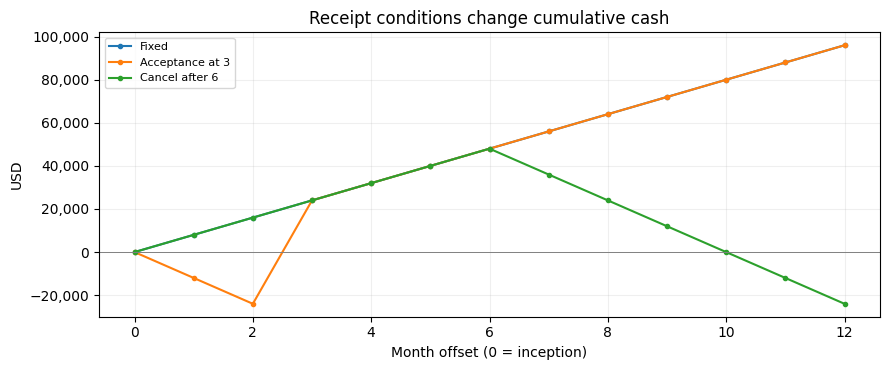

In [5]:
fixed = build_offtake_receipts(terms)
accepted = build_offtake_receipts(
    replace(terms, acceptance_required=True), acceptance_month=3
)
cancelled = build_offtake_receipts(replace(terms, cancellation_after_month=6))
scenarios = {"Fixed": fixed, "Acceptance at 3": accepted, "Cancel after 6": cancelled}


def cfads(rows):
    payments = operating_payments_usd + (0,) * (len(rows) - len(operating_payments_usd))
    return cash_available_for_debt_service_usd([r.receipts_usd for r in rows], payments)


def summarize(scenarios):
    show_finance_table(
        [
            "Scenario",
            "Cash received (USD)",
            "Total CFADS (USD)",
            "Initial buffer (USD)",
        ],
        [
            [
                name,
                sum(r.receipts_usd for r in rows),
                sum(cfads(rows)),
                maximum_funding_requirement_usd(cfads(rows)),
            ]
            for name, rows in scenarios.items()
        ],
    )


summarize(scenarios)
display(
    plot_finance_series(
        {name: tuple(accumulate(cfads(rows))) for name, rows in scenarios.items()},
        title="Receipt conditions change cumulative cash",
    )
)


def receipt_explorer(values, source_terms=terms, supplier=operating_payments_usd):
    from itertools import accumulate

    from liquid_compute.offtake import (
        build_offtake_receipts,
        cash_available_for_debt_service_usd,
    )

    current = replace(
        source_terms,
        acceptance_required=True,
        cancellation_after_month=values["Last service month"],
    )
    rows = build_offtake_receipts(current, acceptance_month=values["Acceptance month"])
    cash = cash_available_for_debt_service_usd([r.receipts_usd for r in rows], supplier)
    return {"Cumulative CFADS": tuple(accumulate(cash))}


explore_finance_series(
    {"Acceptance month": 3, "Last service month": 12},
    receipt_explorer,
    title="Acceptance and cancellation change cash",
);

The normal monthly plan leaves USD 96,000 over the year and needs no extra starting money for these supplier bills. Acceptance in month 3 leaves the same total, but needs USD 24,000 earlier.

Cancellation is different: some customer money never comes at all.

## Experiment 1 · Wait longer for acceptance

Move acceptance to month 5. Keep all 12 service months and bill amounts the same.

Now we must cover four supplier bills before customer money comes. Our contract says the waiting customer bills are paid together at acceptance. They have not been canceled.

In [6]:
acceptance_month = 5
later_acceptance = build_offtake_receipts(
    replace(terms, acceptance_required=True), acceptance_month=acceptance_month
)
summarize({"Acceptance at 3": accepted, "Acceptance at 5": later_acceptance})

| Scenario | Cash received (USD) | Total CFADS (USD) | Initial buffer (USD) |
| --- | --- | --- | --- |
| Acceptance at 3 | 240,000.00 | 96,000.00 | 24,000.00 |
| Acceptance at 5 | 240,000.00 | 96,000.00 | 48,000.00 |

Waiting until month 5 raises the starting cash need to USD 48,000. The whole-year leftover amount is still USD 96,000.

The project needs funding during the wait even though the eventual customer receipts are unchanged. Later cash cannot meet earlier supplier payments without a source of bridging funds.

## Experiment 2 · The customer stops after month 6

The customer pays for six months, including month 6, then stops buying. We get no extra cancellation payment. We also have no right to cancel the supplier bills.

Keep all 12 supplier payments in the example. This changes the amount of money, not just its timing.

In [7]:
show_finance_table(
    ["Month", "Billings (USD)", "Cash (USD)", "Supplier cash (USD)"],
    [
        [
            r.month_offset,
            r.billings_usd,
            r.receipts_usd,
            operating_payments_usd[r.month_offset],
        ]
        for r in cancelled
        if r.month_offset in (6, 7, 12)
    ],
)
summarize({"Cancelled": cancelled})

| Month | Billings (USD) | Cash (USD) | Supplier cash (USD) |
| --- | --- | --- | --- |
| 6.00 | 20,000.00 | 20,000.00 | 12,000.00 |
| 7.00 | 0.00 | 0.00 | 12,000.00 |
| 12.00 | 0.00 | 0.00 | 12,000.00 |

| Scenario | Cash received (USD) | Total CFADS (USD) | Initial buffer (USD) |
| --- | --- | --- | --- |
| Cancelled | 120,000.00 | -24,000.00 | 24,000.00 |

The customer pays USD 120,000, but we pay the supplier USD 144,000. Cash retained from earlier months covers some later bills. We still need USD 24,000 extra overall.

There are no owned GPUs to sell and fill the gap.

## Experiment 3 · Late payment or a smaller bill?

In one case, month 7's USD 20,000 payment arrives in month 10 instead. It is still owed.

In a separate case, month 4 gets a 20% service credit. That part of the bill is removed for good.

We track the original service month so a late bill is not counted as two customer payments.

In [8]:
late = build_offtake_receipts(terms, collection_month_by_service_month={7: 10})
credited = build_offtake_receipts(
    replace(terms, credits_usd=(0, 0, 0, 4_000) + (0,) * 8)
)
summarize({"Fixed": fixed, "Late month 7": late, "Service credit": credited})
show_finance_table(
    ["Late-payment boundary", "Unpaid due (USD)"],
    [[m, late[m].unpaid_due_usd] for m in (7, 9, 10)],
)

| Scenario | Cash received (USD) | Total CFADS (USD) | Initial buffer (USD) |
| --- | --- | --- | --- |
| Fixed | 240,000.00 | 96,000.00 | 0.00 |
| Late month 7 | 240,000.00 | 96,000.00 | 0.00 |
| Service credit | 236,000.00 | 92,000.00 | 0.00 |

| Late-payment boundary | Unpaid due (USD) |
| --- | --- |
| 7.00 | 20,000.00 |
| 9.00 | 20,000.00 |
| 10.00 | 0.00 |

The late-payment case shows USD 20,000 owed in months 7–9. It is paid in month 10. The year's leftover cash stays USD 96,000. Cash retained from earlier months covers the wait in this particular example.

The credit cuts the year's leftover cash to USD 92,000. That money will not arrive later.

## Use the contract terms to build a repayment cash schedule

Identify the customer’s purchase commitment, payment conditions, cancellation rights and actual collection dates.

The table compares the resulting cash schedules without assuming lender approval. F4 then uses a selected schedule to calculate the debt it could support under stated repayment rules.

In [9]:
summarize(scenarios | {"Late collection": late, "Service credit": credited})

| Scenario | Cash received (USD) | Total CFADS (USD) | Initial buffer (USD) |
| --- | --- | --- | --- |
| Fixed | 240,000.00 | 96,000.00 | 0.00 |
| Acceptance at 3 | 240,000.00 | 96,000.00 | 24,000.00 |
| Cancel after 6 | 120,000.00 | -24,000.00 | 24,000.00 |
| Late collection | 240,000.00 | 96,000.00 | 0.00 |
| Service credit | 236,000.00 | 92,000.00 | 0.00 |

**Next: F4 · How big a loan can these payments support?**

Headline contract revenue is only a starting point. Financing depends on the cash that becomes available after applying the contract’s payment and cancellation terms.

The [World Bank](https://ppp.worldbank.org/financing/issues-in-project-financed-transactions) discusses project income and loan payments. The [SEC guide](https://www.sec.gov/about/reports-publications/investorpubsbegfinstmtguide) explains why cash and income are different. Our contracts are hypothetical, and the numbers come from our example.